In [1]:
import os

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../../instrument/')
from Agilent.instr_N9928A import N9928A

In [2]:
_address = "10.0.100.110"
_instr = N9928A(_address)

ConnectionError: Failed to connect to N9928A: [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond

In [ ]:
# with xr.open_zarr("k1.zarr") as f:
#     raw_data = f['S21']

# RO resonator (S5)

K4 -> S5

In [7]:
_instr.reference('EXT')
_instr.center_frequency(8.5805e9)
_instr.span(50e6)
_instr.if_frequency(1e3)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [8]:
res_1 = _instr.get_trace()
res_1.to_zarr('K4_S5.zarr', mode='w')

FileExistsError: Cannot create '' with mode 'w-' because it already contains data. Use mode 'w' to overwrite or 'a' to append.

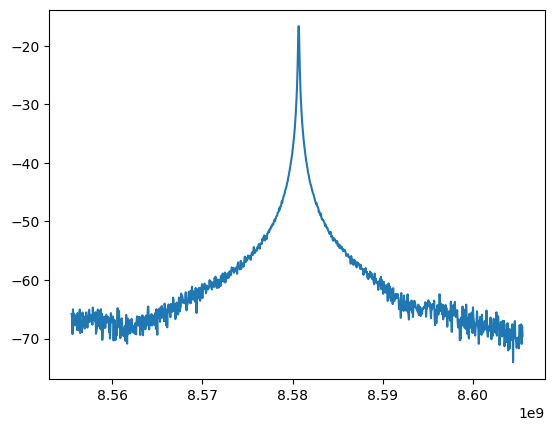

In [14]:
plt.figure()
plt.plot(res_1.frequency_hz, 20*np.log10(np.abs(res_1.data)))
plt.show()

K3 -> S5

In [19]:
_instr.reference('EXT')
_instr.center_frequency(8.5806e9)
_instr.span(2e6)
_instr.if_frequency(1e3)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [193]:
# res_2 = _instr.get_trace()
# res_2.to_zarr('K3_S5.zarr', mode='w')

NameError: name '_instr' is not defined

In [80]:
import os

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../../instrument/')
from Agilent.instr_N9928A import N9928A

In [6]:
with xr.open_zarr("K3_S5.zarr") as f:
    raw_data = f['S21']

In [164]:
with xr.open_zarr("K2_S7.zarr") as f:
    raw_data = f['S21']

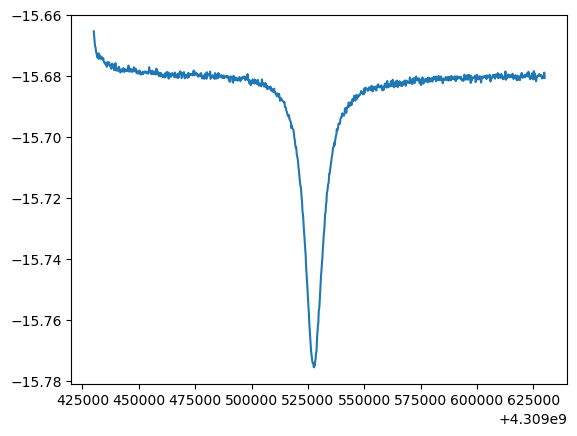

In [165]:
plt.figure()
plt.plot(raw_data.frequency_hz, 20*np.log10(np.abs(raw_data.data)))
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from scipy.optimize import least_squares

# %% 1. data structure
res_all = {}

@dataclass
class ScatteringCoefficient:
    f: np.ndarray
    s: np.ndarray = None

    s_c: complex = None
    r_c: float = None

    s_on: complex = None
    s_off: complex = None

    re: np.ndarray = None
    im: np.ndarray = None

    am: np.ndarray = None
    ph: np.ndarray = None

    def __post_init__(self):
        self.f = self.f.astype(float)
        if (self.s.any() == None):
            if (self.re.any() != None) and (self.im.any() != None):
                self.s = np.array(self.re) + 1j * np.array(self.im)
                self.am = np.abs(self.s)
                self.ph = np.angle(self.s)
            elif (self.am.any() != None) and (self.ph.any() != None):
                self.s = np.array(self.am) * np.exp(1j * self.ph)
                self.re = np.real(self.s)
                self.im = np.imag(self.s)
            else:
                print("invalid data")
        else:
            self.re = np.real(self.s)
            self.im = np.imag(self.s)
            self.am = np.abs(self.s)
            self.ph = np.angle(self.s)

        self.ph = np.unwrap(self.ph)

        if (self.s_on != None) and (self.s_off != None):
            self.s_c = (self.s_on + self.s_off) / 2
            self.r_c = np.abs(self.s_on - self.s_c)

In [8]:
f_data = raw_data.frequency_hz.data /1e9
s_data = raw_data.data

In [9]:
raw_data.frequency_hz.data

array([8.579600e+09, 8.579602e+09, 8.579604e+09, ..., 8.581596e+09,
       8.581598e+09, 8.581600e+09])

In [10]:
f = np.unique(f_data.real)
s = []
for f_x in f:
    ind_x = np.where(f_data == f_x)
    ind_x = ind_x[0].astype('int')
    s.append(np.mean(s_data[ind_x]))
s = np.array(s)

# f = np.linspace(285.35E6, 285.5E6, 10001)
data_raw = ScatteringCoefficient(f=f, s=s)

In [11]:
# %% 3. correction
# 3.1 rough phase correction
params_fit = np.polyfit(data_raw.f, data_raw.ph, 1)
poly_fit = np.poly1d(params_fit)
ph_fit = poly_fit(data_raw.f)

res_all['ph_guess/f'] = params_fit[0]


# 3.2 3db truncation
def LorentzianFit(params, data):
    a1, a2, fr, df = params
    am_fit = np.sqrt(np.abs(a1 - a2 / (1 + (2 * (data.f - fr) / df) ** 2)))
    return am_fit


def LinewidthEstimation(params, data):
    am_fit = LorentzianFit(params, data)
    return am_fit - data.am


params_guess = [1, 1 - data_raw.am.min() ** 2, (data_raw.f[0] + data_raw.f[-1]) / 2,
                (data_raw.f[-1] - data_raw.f[0]) / 5]
params = least_squares(LinewidthEstimation, params_guess, args=(data_raw,))
am_fit = LorentzianFit(params.x, data_raw)

Nd = 3
a1, a2, fr, df = params.x
df = np.abs(df)

Index_3dB = np.logical_and((fr - Nd * df / 2) <= data_raw.f, data_raw.f <= (fr + Nd * df / 2))
data_3dB = ScatteringCoefficient(f=data_raw.f[Index_3dB], s=data_raw.s[Index_3dB])

res_all['fr_guess'] = fr
res_all['df_guess'] = df
res_all['Ql_guess'] = fr / df


# 3.3 fine phase correction
def CircleFit(s_new):
    x, y, z = s_new.real, s_new.imag, np.abs(s_new) ** 2

    M = np.zeros((4, 4))
    M[0, 0] = np.dot(z, z)
    M[0, 1] = np.dot(x, z)
    M[0, 2] = np.dot(y, z)
    M[0, 3] = np.sum(z)
    M[1, 1] = np.dot(x, x)
    M[1, 2] = np.dot(x, y)
    M[1, 3] = np.sum(x)
    M[2, 2] = np.dot(y, y)
    M[2, 3] = np.sum(y)
    M[3, 3] = len(s_new)
    M[1, 0] = M[0, 1]
    M[2, 0] = M[0, 2]
    M[2, 1] = M[1, 2]
    M[3, 0] = M[0, 3]
    M[3, 1] = M[1, 3]
    M[3, 2] = M[2, 3]

    X = np.zeros((4, 4))
    X[0, 3] = -0.5
    X[1, 1] = 1
    X[2, 2] = 1
    X[3, 0] = -0.5

    eta, A = np.linalg.eig(X @ M)
    num = np.where(eta > 0, eta, np.inf).argmin()
    opt = A[:, num]

    f = np.sqrt(np.abs(opt[1] ** 2 + opt[2] ** 2 - 4 * opt[0] * opt[3]))
    opt = opt / f

    xc = -opt[1] / (2 * opt[0])
    yc = -opt[2] / (2 * opt[0])
    rc = 1 / (2 * np.abs(opt[0]))
    return [xc, yc, rc]


def PhaseCorrection(params, data):
    s_new = data.s * np.exp(-1j * params * data.f)
    x, y = s_new.real, s_new.imag
    xc, yc, rc = CircleFit(s_new)
    r1 = np.sqrt((xc - x) ** 2 + (yc - y) ** 2)
    return r1 - rc


params = least_squares(PhaseCorrection, res_all['ph_guess/f'], args=(data_3dB,))
params_fit = params.x[0]
s_cf = data_3dB.s * np.exp(-1j * params_fit * data_3dB.f)
xc_cf, yc_cf, rc_cf = CircleFit(s_cf)
data_cf = ScatteringCoefficient(f=data_3dB.f, s=s_cf, s_c=(xc_cf + 1j * yc_cf), r_c=rc_cf)
res_all['ph/f'] = params_fit


In [12]:
# 3.4 phase versus frequency fit
def PhasefrequencyFit(params, f):
    theta0, Ql, f0 = params
    ph_fit = theta0 + 2 * np.arctan(2 * Ql * (1 - f / f0))
    return ph_fit


def LocateFr(params, data):
    ph_fit = PhasefrequencyFit(params, data.f)
    return ph_fit - data.ph


data_pf = ScatteringCoefficient(f=data_cf.f, s=data_cf.s - data_cf.s_c)
params_guess = [data_pf.ph[0] - np.pi, fr / df, fr]
params = least_squares(LocateFr, params_guess, args=(data_pf,))
theta0, Ql, fr = params.x

data_pf.s = data_pf.s * np.exp(-1j * theta0)
data_pf = ScatteringCoefficient(**data_pf.__dict__)

ph_pf_on = PhasefrequencyFit(params.x, fr)
data_cf.s_on = rc_cf * np.exp(1j * ph_pf_on) + data_cf.s_c
data_cf.s_off = -rc_cf * np.exp(1j * ph_pf_on) + data_cf.s_c

res_all['fr'] = fr
res_all['df'] = fr / Ql
res_all['Ql'] = Ql

In [13]:
# 3.5 canonical transform
data_ct = ScatteringCoefficient(f=data_cf.f, s=data_cf.s / data_cf.s_off)
data_ct.s_on = data_cf.s_on / data_cf.s_off
data_ct.s_off = 1 + 0j
data_ct = ScatteringCoefficient(**data_ct.__dict__)

# 3.6 asymmetry correction
s_fc = data_ct.s_c - (1 + 0j)
ph_asy = np.angle(s_fc) - np.pi
am_asy = np.abs(np.cos(ph_asy))
s_ac = (data_ct.s - (1 + 0j)) * np.exp(-1j * ph_asy) * am_asy + (1 + 0j)

data_ac = ScatteringCoefficient(f=data_ct.f, s=s_ac)
data_ac.s_on = (data_ct.s_on - (1 + 0j)) * np.exp(-1j * ph_asy) * am_asy + (1 + 0j)
data_ac.s_off = 1 + 0j
data_ac = ScatteringCoefficient(**data_ac.__dict__)

res_all['ph_asy'] = ph_asy

Qe = res_all['Ql'] / (2 * data_ct.r_c) * np.exp(-1j * ph_asy)
res_all['Qe'] = Qe
# res_all['ReQe'] = 1/np.real(1/Qe)
res_all['ReQe'] = res_all['Ql'] / (2 * data_ac.r_c)
res_all['Qi'] = 1 / (1 / res_all['Ql'] - 1 / res_all['ReQe'])

In [14]:
res_all

{'ph_guess/f': -247.67904406804044,
 'fr_guess': 8.580675448345866,
 'df_guess': 9.944043697284804e-05,
 'Ql_guess': 86289.59917672926,
 'ph/f': -1391.2790019077615,
 'fr': 8.580675485734067,
 'df': 0.00016998270533809742,
 'Ql': 50479.697147230436,
 'ph_asy': -6.282035528726912,
 'Qe': (92776.3308887151-106.67227318065827j),
 'ReQe': 92776.45353825035,
 'Qi': 110725.4474482421}

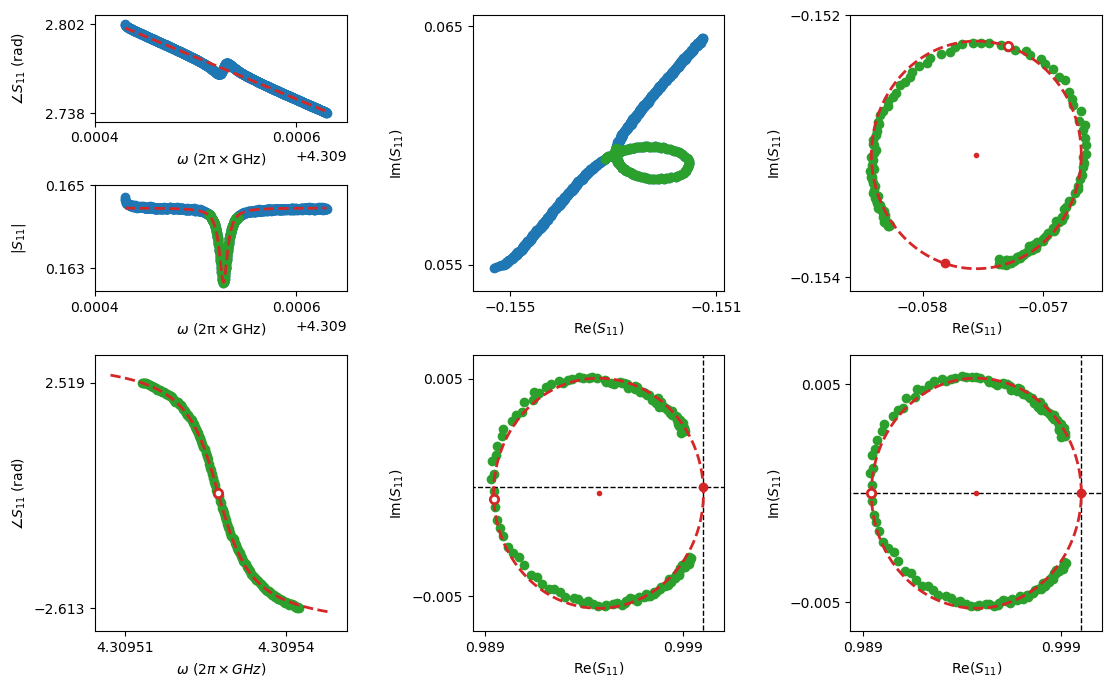

In [192]:
# %% 4. plots
fig = plt.figure(figsize=(13, 8))
grid = plt.GridSpec(4, 3, wspace=0.5, hspace=0.6)

# 4.1
f_range = data_raw.f.max() - data_raw.f.min()
ph_range = data_raw.ph.max() - data_raw.ph.min()
am_range = data_raw.am.max() - data_raw.am.min()

ax1a = plt.subplot(grid[0, 0])
ax1a.scatter(data_raw.f, data_raw.ph, color='C0')
ax1a.plot(data_raw.f, ph_fit, linewidth=2, linestyle='--', color='C3')
ax1a.set_xlabel(r'$\omega$ ($\rm 2\pi\times GHz$)')
ax1a.set_ylabel(r'$\angle S_{11}$ (rad)')
ax1a.set_xlim(data_raw.f.min() - f_range / 10, data_raw.f.max() + f_range / 10)
ax1a.set_ylim(data_raw.ph.min() - ph_range / 10, data_raw.ph.max() + ph_range / 10)

ax1a.set_xticks([float("{:.4f}".format(data_raw.f.min())), float("{:.4f}".format(data_raw.f.max()))])
ax1a.set_yticks([float("{:.3f}".format(data_raw.ph.min())), float("{:.3f}".format(data_raw.ph.max()))])

ax1b = plt.subplot(grid[1, 0])
ax1b.scatter(data_raw.f, data_raw.am, color='C0')
ax1b.scatter(data_3dB.f, data_3dB.am, color='C2')
ax1b.plot(data_raw.f, am_fit, linewidth=2, linestyle='--', color='C3')
ax1b.set_xlabel(r'$\omega$ ($\rm 2\pi\times GHz$)')
ax1b.set_ylabel(r'$|S_{11}|$')
ax1b.set_xlim(data_raw.f.min() - f_range / 10, data_raw.f.max() + f_range / 10)
ax1b.set_ylim(data_raw.am.min() - am_range / 10, data_raw.am.max() + am_range / 10)

ax1b.set_xticks([float("{:.4f}".format(data_raw.f.min())), float("{:.4f}".format(data_raw.f.max()))])
ax1b.set_yticks([float("{:.3f}".format(data_raw.am.min())), float("{:.3f}".format(data_raw.am.max()))])

# 4.2
re_range = data_raw.re.max() - data_raw.re.min()
im_range = data_raw.im.max() - data_raw.im.min()

ax2 = plt.subplot(grid[:2, 1])
ax2.scatter(data_raw.re, data_raw.im, color='C0')
ax2.scatter(data_3dB.re, data_3dB.im, color='C2')
ax2.set_xlim(data_raw.re.min() - re_range / 10, data_raw.re.max() + re_range / 10)
ax2.set_ylim(data_raw.im.min() - im_range / 10, data_raw.im.max() + im_range / 10)
ax2.set_xlabel(r'${\rm Re}\left( S_{11} \right)$')
ax2.set_ylabel(r'${\rm Im}\left( S_{11} \right)$')

ax2.set_xticks([float("{:.3f}".format(data_raw.re.min())), float("{:.3f}".format(data_raw.re.max()))])
ax2.set_yticks([float("{:.3f}".format(data_raw.im.min())), float("{:.3f}".format(data_raw.im.max()))])

# 4.3
s_cf_fit = data_cf.r_c * np.exp(1j * np.linspace(0, 2 * np.pi, 1001)) + data_cf.s_c
re_range = s_cf_fit.real.max() - s_cf_fit.real.min()
im_range = s_cf_fit.imag.max() - s_cf_fit.imag.min()

ax3 = plt.subplot(grid[:2, 2])
ax3.scatter(data_cf.re, data_cf.im, color='C2', zorder=0)
ax3.plot(s_cf_fit.real, s_cf_fit.imag, linewidth=2, linestyle='--', color='C3', zorder=0)
ax3.scatter(xc_cf, yc_cf, marker='.', color='C3')
ax3.scatter(data_cf.s_on.real, data_cf.s_on.imag, linewidths=2, color='white', edgecolor='C3')
ax3.scatter(data_cf.s_off.real, data_cf.s_off.imag, color='C3')

ax3.set_xlim(s_cf_fit.real.min() - re_range / 10, s_cf_fit.real.max() + re_range / 10)
ax3.set_ylim(s_cf_fit.imag.min() - im_range / 10, s_cf_fit.imag.max() + im_range / 10)
ax3.set_xlabel(r'${\rm Re}\left( S_{11} \right)$')
ax3.set_ylabel(r'${\rm Im}\left( S_{11} \right)$')

ax3.set_xticks([float("{:.3f}".format(data_cf.re.min())), float("{:.3f}".format(data_cf.re.max()))])
ax3.set_yticks([float("{:.3f}".format(data_cf.im.min())), float("{:.3f}".format(data_cf.im.max()))])

# 4.4
f_range = data_pf.f.max() - data_pf.f.min()
f_sim = np.linspace(data_pf.f.min() - f_range / 5, data_pf.f.max() + f_range / 5, 1001)
ph_pf_fit = PhasefrequencyFit([0, res_all['Ql'], res_all['fr']], f_sim)

ax4 = plt.subplot(grid[2:, 0])
ax4.scatter(data_pf.f, data_pf.ph, color='C2', zorder=0)
ax4.plot(f_sim, ph_pf_fit, linewidth=2, linestyle='--', color='C3')
ax4.scatter(res_all['fr'], 0, linewidths=2, color='white', edgecolor='C3', zorder=100)

ax4.set_xlim(data_pf.f.min() - f_range * 3 / 10, data_pf.f.max() + f_range * 3 / 10)
ax4.set_ylim(-np.pi, np.pi)
ax4.set_xlabel(r'$\omega$ ($2\pi\times GHz$)')
ax4.set_ylabel(r'$\angle S_{11}$ (rad)')

ax4.set_xticks([float("{:.5f}".format(data_pf.f.min())), float("{:.5f}".format(data_pf.f.max()))])
ax4.set_yticks([float("{:.3f}".format(data_pf.ph.min())), float("{:.3f}".format(data_pf.ph.max()))])
ax4.ticklabel_format(useOffset=False)

# 4.5
s_ct_fit = data_ct.r_c * np.exp(1j * np.linspace(0, 2 * np.pi, 1001)) + data_ct.s_c
re_range = s_ct_fit.real.max() - s_ct_fit.real.min()
im_range = s_ct_fit.imag.max() - s_ct_fit.imag.min()

ax5 = plt.subplot(grid[2:, 1])
ax5.scatter(data_ct.re, data_ct.im, color='C2', zorder=0)
ax5.plot(s_ct_fit.real, s_ct_fit.imag, linewidth=2, linestyle='--', color='C3')
ax5.scatter(data_ct.s_c.real, data_ct.s_c.imag, marker='.', color='C3')
ax5.scatter(data_ct.s_on.real, data_ct.s_on.imag, linewidths=2, color='white', edgecolor='C3', zorder=100)
ax5.scatter(data_ct.s_off.real, data_ct.s_off.imag, color='C3')

ax5.hlines(y=0, xmin=-2, xmax=2, color='black', linestyle='--', linewidth=1, zorder=0)
ax5.vlines(x=1, ymin=-2, ymax=2, color='black', linestyle='--', linewidth=1, zorder=0)
ax5.set_xlim(s_ct_fit.real.min() - re_range / 10, s_ct_fit.real.max() + re_range / 10)
ax5.set_ylim(s_ct_fit.imag.min() - im_range / 10, s_ct_fit.imag.max() + im_range / 10)
ax5.set_xlabel(r'${\rm Re}\left( S_{11} \right)$')
ax5.set_ylabel(r'${\rm Im}\left( S_{11} \right)$')

ax5.set_xticks([float("{:.3f}".format(data_ct.re.min())), float("{:.3f}".format(data_ct.re.max()))])
ax5.set_yticks([float("{:.3f}".format(data_ct.im.min())), float("{:.3f}".format(data_ct.im.max()))])

# 4.6
s_ac_fit = data_ac.r_c * np.exp(1j * np.linspace(0, 2 * np.pi, 1001)) + data_ac.s_c
re_range = s_ac_fit.real.max() - s_ac_fit.real.min()
im_range = s_ac_fit.imag.max() - s_ac_fit.imag.min()

ax6 = plt.subplot(grid[2:, 2])
ax6.scatter(data_ac.re, data_ac.im, color='C2', zorder=0)
ax6.plot(s_ac_fit.real, s_ac_fit.imag, linewidth=2, linestyle='--', color='C3')
ax6.scatter(data_ac.s_c.real, data_ac.s_c.imag, marker='.', color='C3')
ax6.scatter(data_ac.s_on.real, data_ac.s_on.imag, linewidths=2, color='white', edgecolor='C3', zorder=100)
ax6.scatter(data_ac.s_off.real, data_ac.s_off.imag, color='C3')

ax6.hlines(y=0, xmin=-2, xmax=2, color='black', linestyle='--', linewidth=1, zorder=0)
ax6.vlines(x=1, ymin=-2, ymax=2, color='black', linestyle='--', linewidth=1, zorder=0)
ax6.set_xlim(s_ac_fit.real.min() - re_range / 10, s_ac_fit.real.max() + re_range / 10)
ax6.set_ylim(s_ac_fit.imag.min() - im_range / 10, s_ac_fit.imag.max() + im_range / 10)
ax6.set_xlabel(r'${\rm Re}\left( S_{11} \right)$')
ax6.set_ylabel(r'${\rm Im}\left( S_{11} \right)$')

ax6.set_xticks([float("{:.3f}".format(data_ac.re.min())), float("{:.3f}".format(data_ac.re.max()))])
ax6.set_yticks([float("{:.3f}".format(data_ac.im.min())), float("{:.3f}".format(data_ac.im.max()))])

fig.align_ylabels()
plt.show()

K2 -> S5

In [26]:
_instr.reference('EXT')
_instr.center_frequency(8.5806e9)
_instr.span(5e6)
_instr.if_frequency(1e3)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [27]:
res_3 = _instr.get_trace()
res_3.to_zarr('K2_S5.zarr', mode='w')

In [4]:
res_3 = raw_data

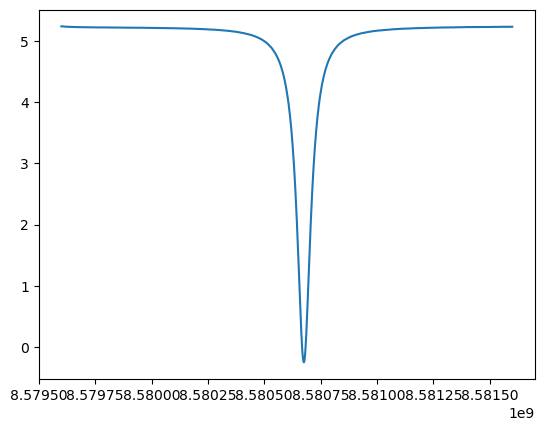

In [5]:
plt.figure()
plt.plot(res_3.frequency_hz, 20*np.log10(np.abs(res_3.data)))
plt.show()

# Memory resonator (S7)

K2 -> S7

In [156]:
_instr.reference('EXT')
_instr.center_frequency(4.30953e9)
_instr.span(0.2e6)
_instr.if_frequency(1e2)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [157]:
res_4 = _instr.get_trace()
res_4.to_zarr('K2_S7.zarr', mode='w')

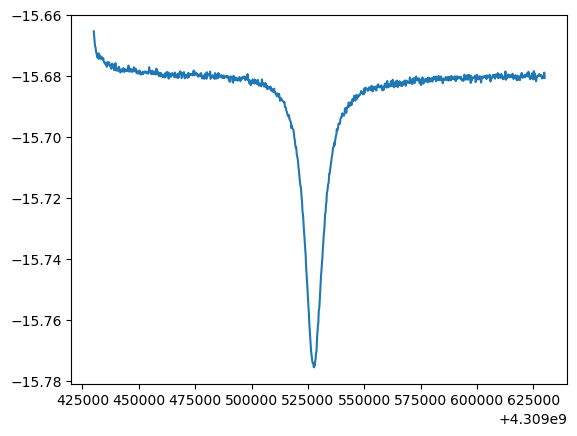

In [158]:
plt.figure()
plt.plot(res_4.frequency_hz, 20*np.log10(np.abs(res_4.data)))
plt.show()

K3 -> S7

In [129]:
_instr.reference('EXT')
_instr.if_frequency(1e3)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [ ]:
res = []
f0_list = np.arange(3.5, 4.5-1e-9, 0.01) * 1e9
for f0 in f0_list:

    _instr.start_frequency(f0)
    _instr.stop_frequency(f0 + 0.01e9)

    res_5 = _instr.get_trace()
    res.append(res_5)

    plt.figure()
    plt.plot(res_5.frequency_hz, 20*np.log10(np.abs(res_5.data)))
    plt.show()

combined_ds = xr.combine_by_coords(res)
res_5 = combined_ds['S21']

res_5.to_zarr('K3_S7.zarr', mode='w')

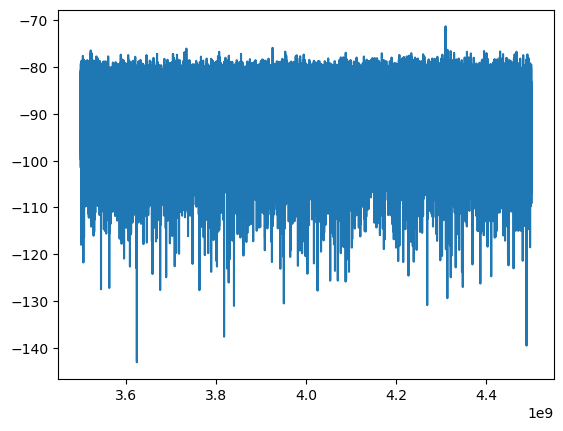

In [131]:
plt.figure()
plt.plot(res_5.frequency_hz, 20*np.log10(np.abs(res_5.data)))
plt.show()

In [162]:
_instr.reference('EXT')
_instr.center_frequency(4.30953e9)
_instr.span(0.2e6)
_instr.if_frequency(1e2)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [163]:
res_5_2 = _instr.get_trace()
res_5_2.to_zarr('K3_S7_2.zarr', mode='w')

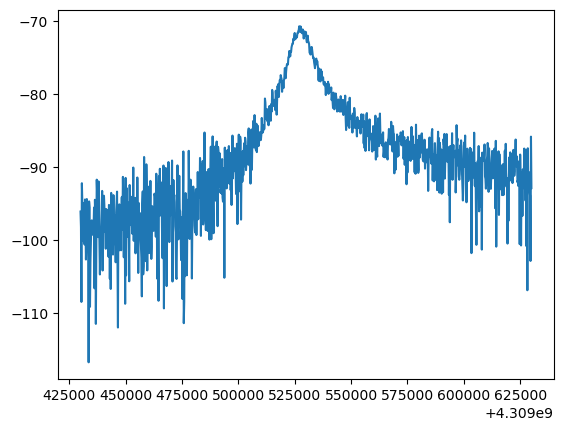

In [164]:
plt.figure()
plt.plot(res_5_2.frequency_hz, 20*np.log10(np.abs(res_5_2.data)))
plt.show()

K4 -> S7

In [168]:
_instr.reference('EXT')
_instr.center_frequency(4.30953e9)
_instr.span(0.2e6)
_instr.if_frequency(1e2)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [169]:
res_6 = _instr.get_trace()
res_6.to_zarr('K4_S7.zarr', mode='w')

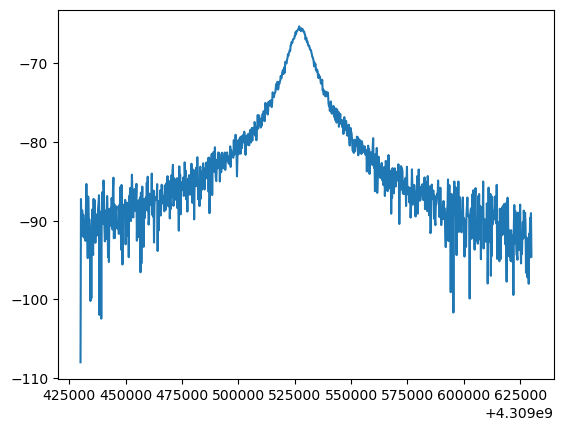

In [170]:
plt.figure()
plt.plot(res_6.frequency_hz, 20*np.log10(np.abs(res_6.data)))
plt.show()

# Test resonator (S6)

K1 -> S6

In [171]:
_instr.reference('EXT')
_instr.if_frequency(1e3)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [ ]:
res = []
f0_list = np.arange(4.0, 4.5-1e-9, 0.01) * 1e9
for f0 in f0_list:

    _instr.start_frequency(f0)
    _instr.stop_frequency(f0 + 0.01e9)

    res_7 = _instr.get_trace()
    res.append(res_7)

    plt.figure()
    plt.plot(res_7.frequency_hz, 20*np.log10(np.abs(res_7.data)))
    plt.show()

combined_ds = xr.combine_by_coords(res)
res_7 = combined_ds['S21']

res_7.to_zarr('K1_S6.zarr', mode='w')

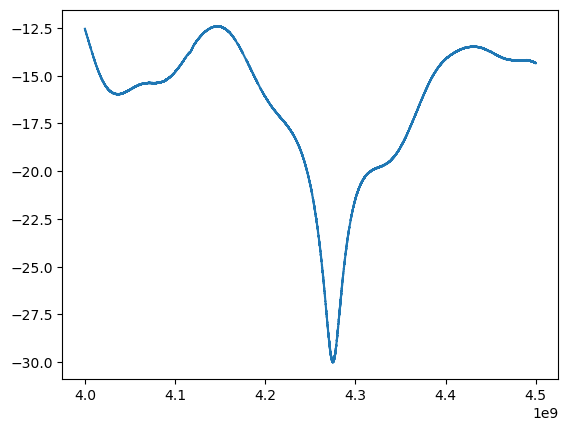

In [173]:
plt.figure()
plt.plot(res_7.frequency_hz, 20*np.log10(np.abs(res_7.data)))
plt.show()

In [180]:
_instr.reference('EXT')
_instr.center_frequency(5.02e9)
_instr.span(10e6)
_instr.if_frequency(1e3)
_instr.average(10, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [181]:
res_7_2 = _instr.get_trace()
res_7_2.to_zarr('K1_S6_2.zarr', mode='w')

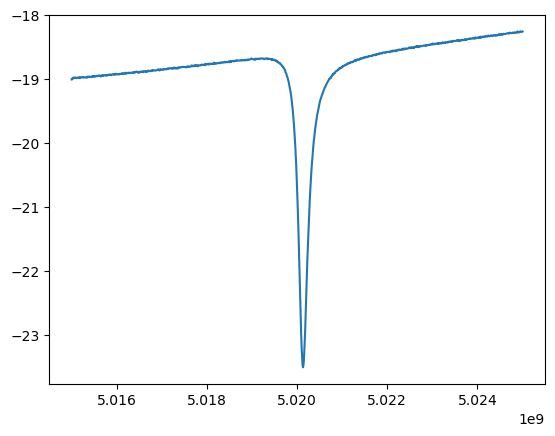

In [182]:
plt.figure()
plt.plot(res_7_2.frequency_hz, 20*np.log10(np.abs(res_7_2.data)))
plt.show()